# 03 — EDA de degradación y análisis pre-falla

Este notebook toma **con evidencia** las tres decisiones que necesita el feature engineering (04):

1. **`RUL_MAX`** — horizonte de predicción (¿cuántas horas antes de la falla empiezan a
   cambiar las señales?).
2. **Tamaño de ventana** — cuántos pasos de historia usar (a partir de la autocorrelación).
3. **Priorización de señales** — cuáles sensores aportan más (correlaciones y comportamiento
   pre-falla).

**Cambio de enfoque respecto a la versión anterior:** ya no es un EDA de "datos sin apagado".
Como el notebook 02 ahora preserva el régimen 0, este notebook analiza la **degradación
temporal** completa hacia cada falla.

## Fuentes de datos y resolución

El notebook 02 guarda a **10 s** nativos:
- `preprocesado_completo.parquet` — todos los regímenes (0/1/2), con continuidad temporal.
  Se usa para la **curva de degradación** y el análisis pre-falla.
- `operacional.parquet` — solo regímenes 1 y 2, con `id_sesion`. Se usa para
  **distribuciones y correlaciones** en operación.

**Decisión de resolución para este EDA:** las fugas de aire se degradan en escala de **horas**.
Para el análisis de degradación, autocorrelación y STL, remuestreamos a **1 minuto** dentro de
este notebook (los parquets de 10 s quedan intactos). 1 min reduce el costo computacional ~6×
y es más que suficiente para detectar tendencias de horas. Los transitorios finos de 10 s se
explotarán, si hace falta, en el feature engineering.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.seasonal import STL
import os

sns.set_style('whitegrid')

ANALOG_COLS = ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs',
               'Oil_temperature', 'Motor_current', 'Caudal_impulses']
BINARY_COLS = ['COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS',
               'Pressure_switch', 'Oil_level']

FALLAS = {
    'Falla 1': '2020-04-18 00:00',
    'Falla 2': '2020-05-29 23:30',
    'Falla 3': '2020-06-05 10:00',
    'Falla 4': '2020-07-15 14:30',
}

## 1. Cargar datos

In [2]:
df_full = pd.read_parquet('../data/processed/preprocesado_completo.parquet')
df_op = pd.read_parquet('../data/processed/operacional.parquet')

print(f'Completo    : {len(df_full):,} filas (regímenes {sorted(df_full["regimen"].unique())})')
print(f'Operacional : {len(df_op):,} filas, {df_op["id_sesion"].nunique()} sesiones')
print(f'Período     : {df_full["timestamp"].min()} -> {df_full["timestamp"].max()}')
df_op.head()

Completo    : 1,514,658 filas (regímenes [np.int64(0), np.int64(1), np.int64(2)])
Operacional : 687,708 filas, 374 sesiones
Período     : 2020-02-01 00:00:00 -> 2020-09-01 03:59:50


,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses,id_segmento,regimen,id_sesion
0,2020-02-01 00:23:00,-0.014,8.068,7.804,-0.024,8.072,49.825,4.3150,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0,2,0
1,2020-02-01 00:23:10,8.436,8.086,-0.028,-0.022,8.082,49.850,5.8400,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0,2,0
2,2020-02-01 00:23:20,8.726,8.380,-0.024,-0.024,8.382,49.675,5.9725,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0,2,0
3,2020-02-01 00:23:30,8.978,8.642,-0.020,-0.024,8.640,49.675,6.0500,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0,2,0
4,2020-02-01 00:23:40,9.218,8.820,-0.020,-0.024,8.816,49.625,6.1025,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0,2,0


## 2. Remuestreo a 1 minuto (solo para este EDA)

Agregamos a 1 min respetando `id_segmento` (no se cruzan gaps). Las analógicas por media,
las binarias por su valor modal/último y el contador por suma. Este `df_min` se usa para
autocorrelación y STL; las distribuciones se calculan sobre los datos operacionales a 10 s.

In [3]:
def resample_1min(df, cols_analog, cols_bin):
    partes = []
    agg = {c: 'mean' for c in cols_analog}
    agg.update({c: 'last' for c in cols_bin})
    agg['Caudal_impulses'] = 'sum'
    agg['regimen'] = 'last'
    for _, g in df.groupby('id_segmento'):
        r = g.set_index('timestamp').resample('1min').agg(agg)
        r['id_segmento'] = g['id_segmento'].iloc[0]
        partes.append(r)
    return pd.concat(partes).reset_index()

analog_sin_caudal = [c for c in ANALOG_COLS if c != 'Caudal_impulses']
df_min = resample_1min(df_full, analog_sin_caudal, BINARY_COLS)
df_min = df_min.dropna(subset=analog_sin_caudal)
print(f'df_min (1 min): {len(df_min):,} filas')
df_min.head()

df_min (1 min): 252,720 filas


,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses,regimen,id_segmento
0,2020-02-01 00:00:00,-0.012167,9.324833,9.308500,-0.023000,9.325500,53.502083,0.040208,1.0,0.0,1.0,1.0,0.0,1.0,1.0,7.0,0,0
1,2020-02-01 00:01:00,-0.013000,9.260000,9.243333,-0.023333,9.259667,53.420833,0.040000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,6.0,0,0
2,2020-02-01 00:02:00,-0.012667,9.198333,9.182000,-0.022333,9.199000,53.325000,0.040000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,6.0,0,0
3,2020-02-01 00:03:00,-0.012333,9.136667,9.120667,-0.022667,9.136667,53.200000,0.040000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,6.0,0,0
4,2020-02-01 00:04:00,-0.013000,9.075667,9.060000,-0.023000,9.075667,53.129167,0.040000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,6.0,0,0


## 3. Distribuciones en operación

Sobre `operacional.parquet` (regímenes 1 y 2), para ver cómo se comportan las señales cuando
el compresor está activo.

In [4]:
print('Estadísticas analógicas (operación):')
display(df_op[ANALOG_COLS].describe().T.style
        .background_gradient(cmap='Blues', subset=['mean', 'std', 'min', 'max'])
        .format(precision=3))

Estadísticas analógicas (operación):


,count,mean,std,min,25%,50%,75%,max
TP2,687708.000,3.054,4.274,-0.032,-0.012,-0.010,8.390,10.676
TP3,687708.000,9.344,0.687,0.730,9.062,9.534,9.794,10.302
H1,687708.000,6.231,4.587,-0.036,-0.010,9.390,9.718,10.288
DV_pressure,687708.000,0.147,0.552,-0.032,-0.022,-0.020,-0.016,9.844
Reservoirs,687708.000,9.343,0.687,0.712,9.062,9.534,9.794,10.300
Oil_temperature,687708.000,66.671,6.039,15.400,63.575,67.350,70.750,89.050
Motor_current,687708.000,4.476,0.978,2.008,3.743,3.835,5.575,9.295
Caudal_impulses,687708.000,0.922,0.296,0.000,1.000,1.000,1.000,2.000


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), ANALOG_COLS):
    sns.histplot(df_op[col], bins=60, kde=True, ax=ax, color='steelblue', alpha=0.7)
    ax.axvline(df_op[col].mean(), color='red', linestyle='--', linewidth=1, label='media')
    ax.axvline(df_op[col].median(), color='green', linestyle='--', linewidth=1, label='mediana')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
axes.flatten()[0].legend(fontsize=9)
plt.suptitle('Distribuciones de sensores analógicos (operación)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Correlaciones entre sensores

Buscamos multicolinealidad para priorizar señales en el feature engineering (evitar
redundancia). Analizamos por régimen porque la relación física cambia bajo carga.

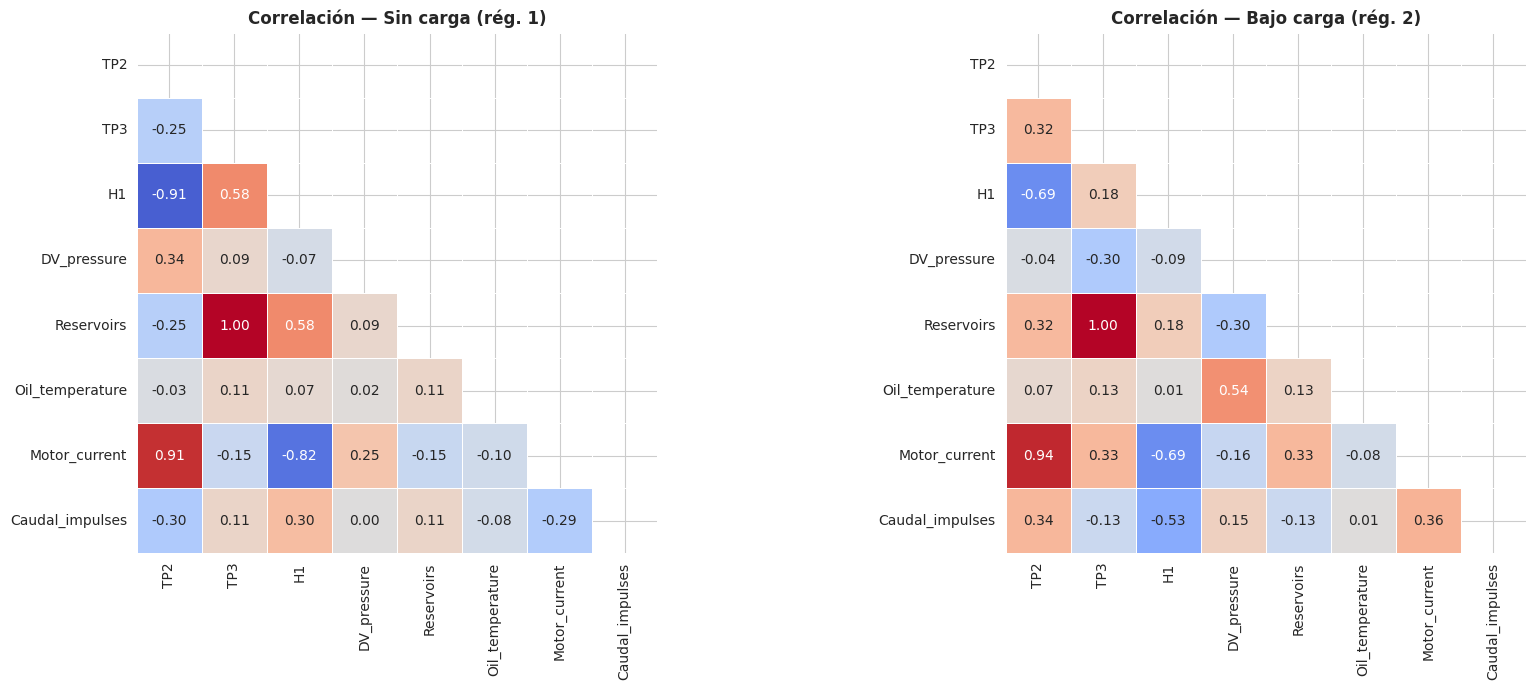

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, (reg, nombre) in zip(axes, [(1, 'Sin carga (rég. 1)'), (2, 'Bajo carga (rég. 2)')]):
    corr = df_op[df_op['regimen'] == reg][ANALOG_COLS].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
                mask=mask, square=True, linewidths=0.5, ax=ax, cbar=False)
    ax.set_title(f'Correlación — {nombre}', fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretación:** TP3 y Reservoirs suelen estar altamente correlacionadas (misma presión
neumática por diseño). Esa redundancia se resolverá en el 04/05 con selección de features
(feature importance de RF, L1, etc.).

## 5. Autocorrelación — memoria temporal para el tamaño de ventana

El ACF nos dice cuántos pasos de historia son informativos. Como la tendencia domina y oculta
el ciclo operacional, calculamos el ACF sobre el **componente estacional** (vía STL) de las
señales, sobre el segmento operativo más largo.

Segmento 74: 6047 min = 100.8 h


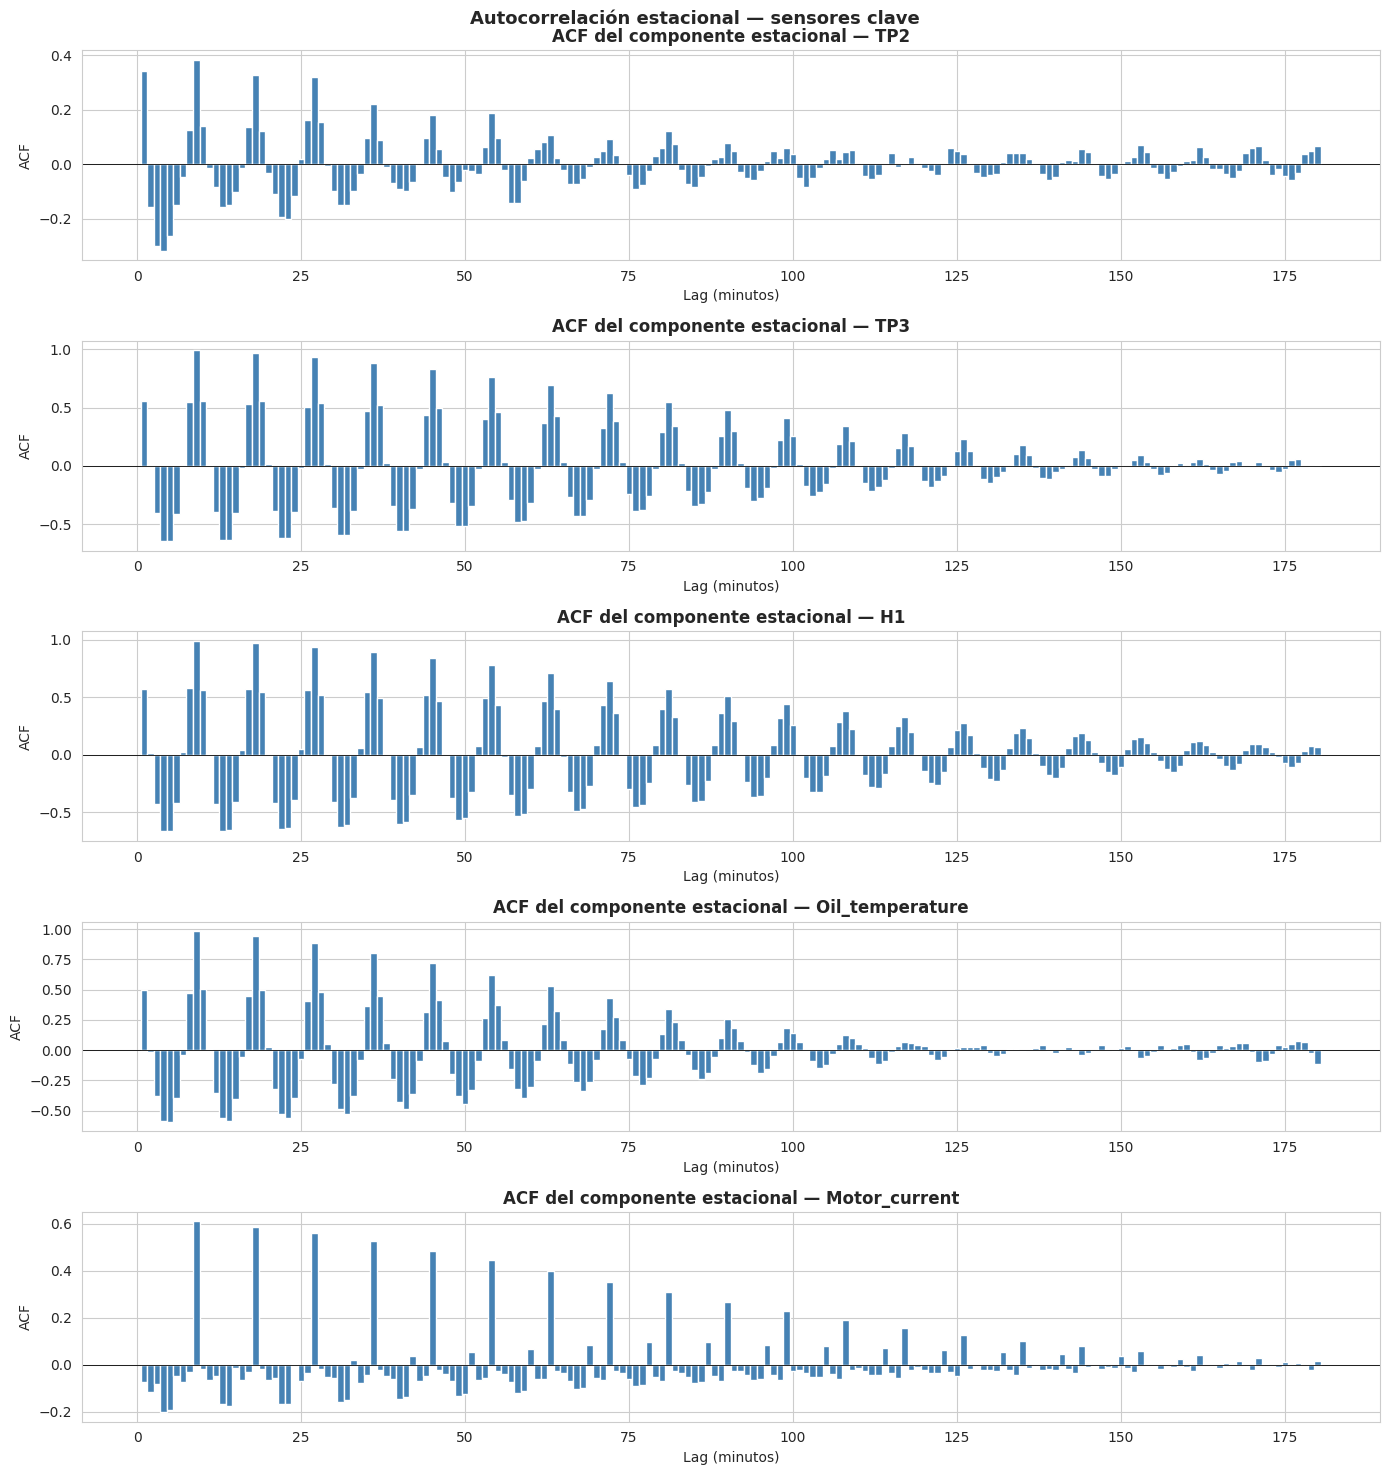

In [ ]:
# Segmento operativo más largo (a 1 min) para el análisis STL/ACF
seg_id = df_min.groupby('id_segmento').size().idxmax()
seg = df_min[df_min['id_segmento'] == seg_id].reset_index(drop=True)
print(f'Segmento {seg_id}: {len(seg)} min = {len(seg)/60:.1f} h')

LAGS = 180  # 180 min = 3 h de historia máxima a evaluar
key = ['TP2', 'TP3', 'H1', 'Oil_temperature', 'Motor_current']

fig, axes = plt.subplots(len(key), 1, figsize=(14, 3 * len(key)))
for ax, col in zip(axes, key):
    serie = seg[col].astype(float)
    # STL requiere periodo; el ciclo operacional ~ 9 min a 1 min de resolución
    estacional = STL(serie, period=9, seasonal=19, robust=True).fit().seasonal
    valores = acf(estacional, nlags=LAGS, fft=True)
    ax.bar(range(1, LAGS + 1), valores[1:], color='steelblue', width=1.0)
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_title(f'ACF del componente estacional — {col}', fontweight='bold')
    ax.set_xlabel('Lag (minutos)')
    ax.set_ylabel('ACF')
plt.suptitle('Autocorrelación estacional — sensores clave', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Lectura:** todas las señales comparten el ciclo operacional de ~9 min (arranque/pausa del
compresor). La memoria significativa se extiende hasta ~1–2 h. Esto acota el tamaño de ventana:
una ventana de **60 min** captura varios ciclos completos sin ser excesivamente costosa.

## 6. Evolución de las señales 72 h antes de cada falla

Usamos `preprocesado_completo.parquet` (con continuidad temporal) para ver cuándo las señales
empiezan a desviarse del comportamiento normal. Esto determina `RUL_MAX`.

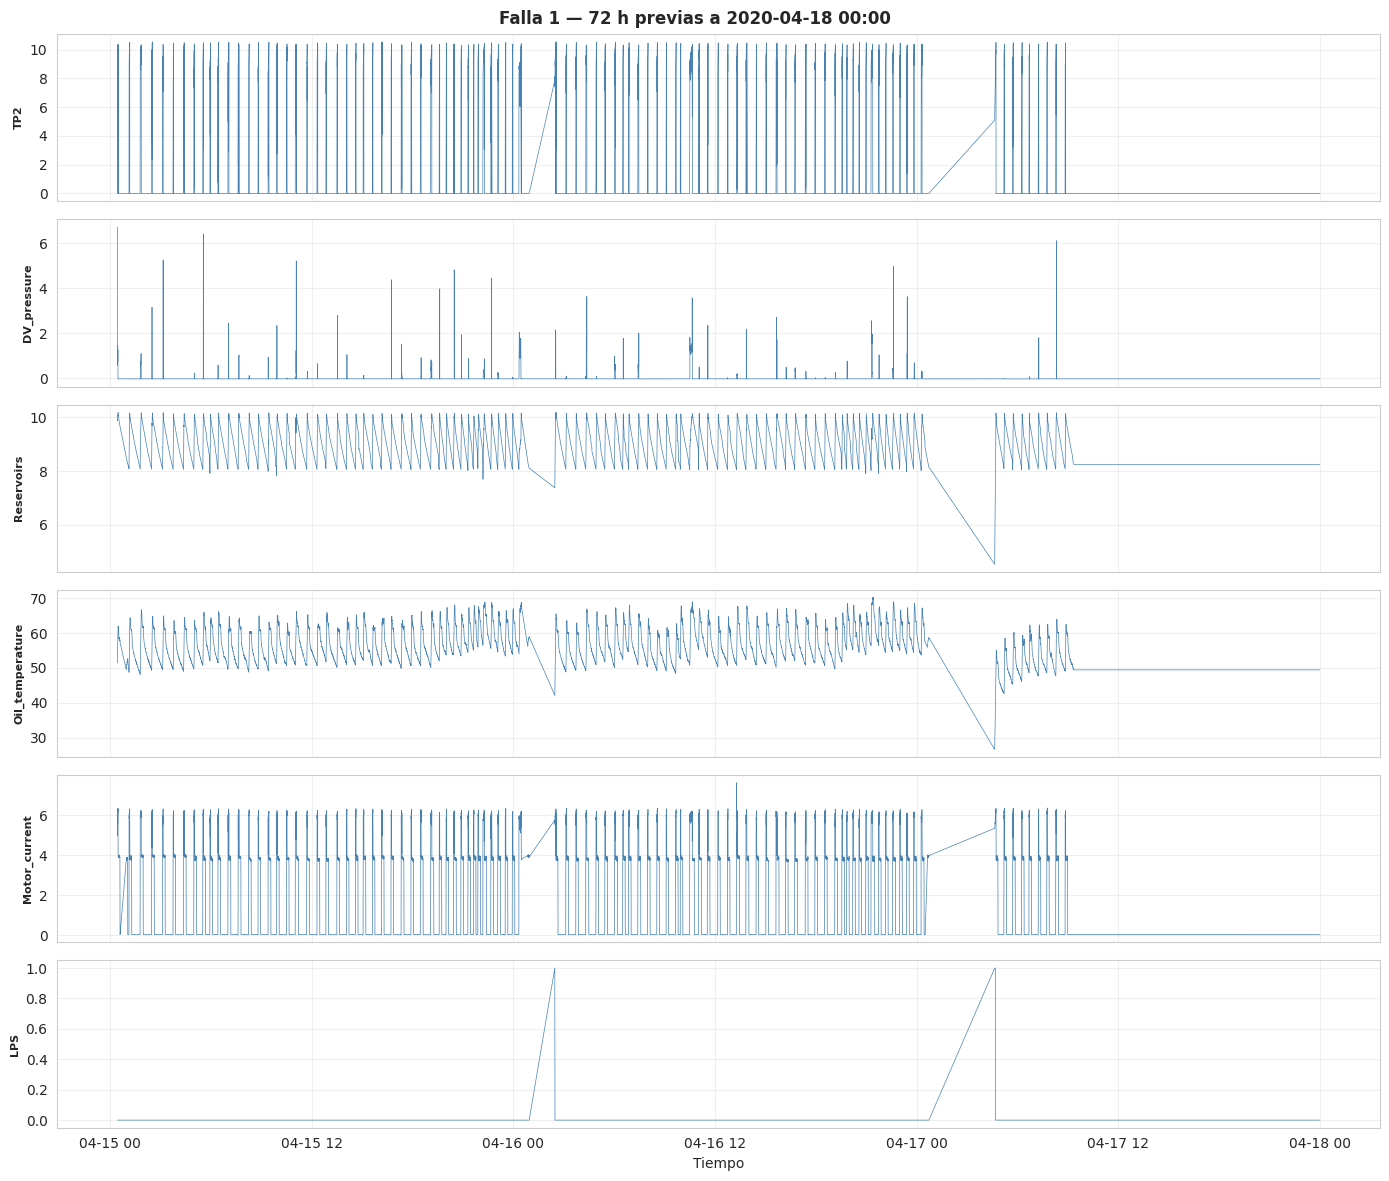

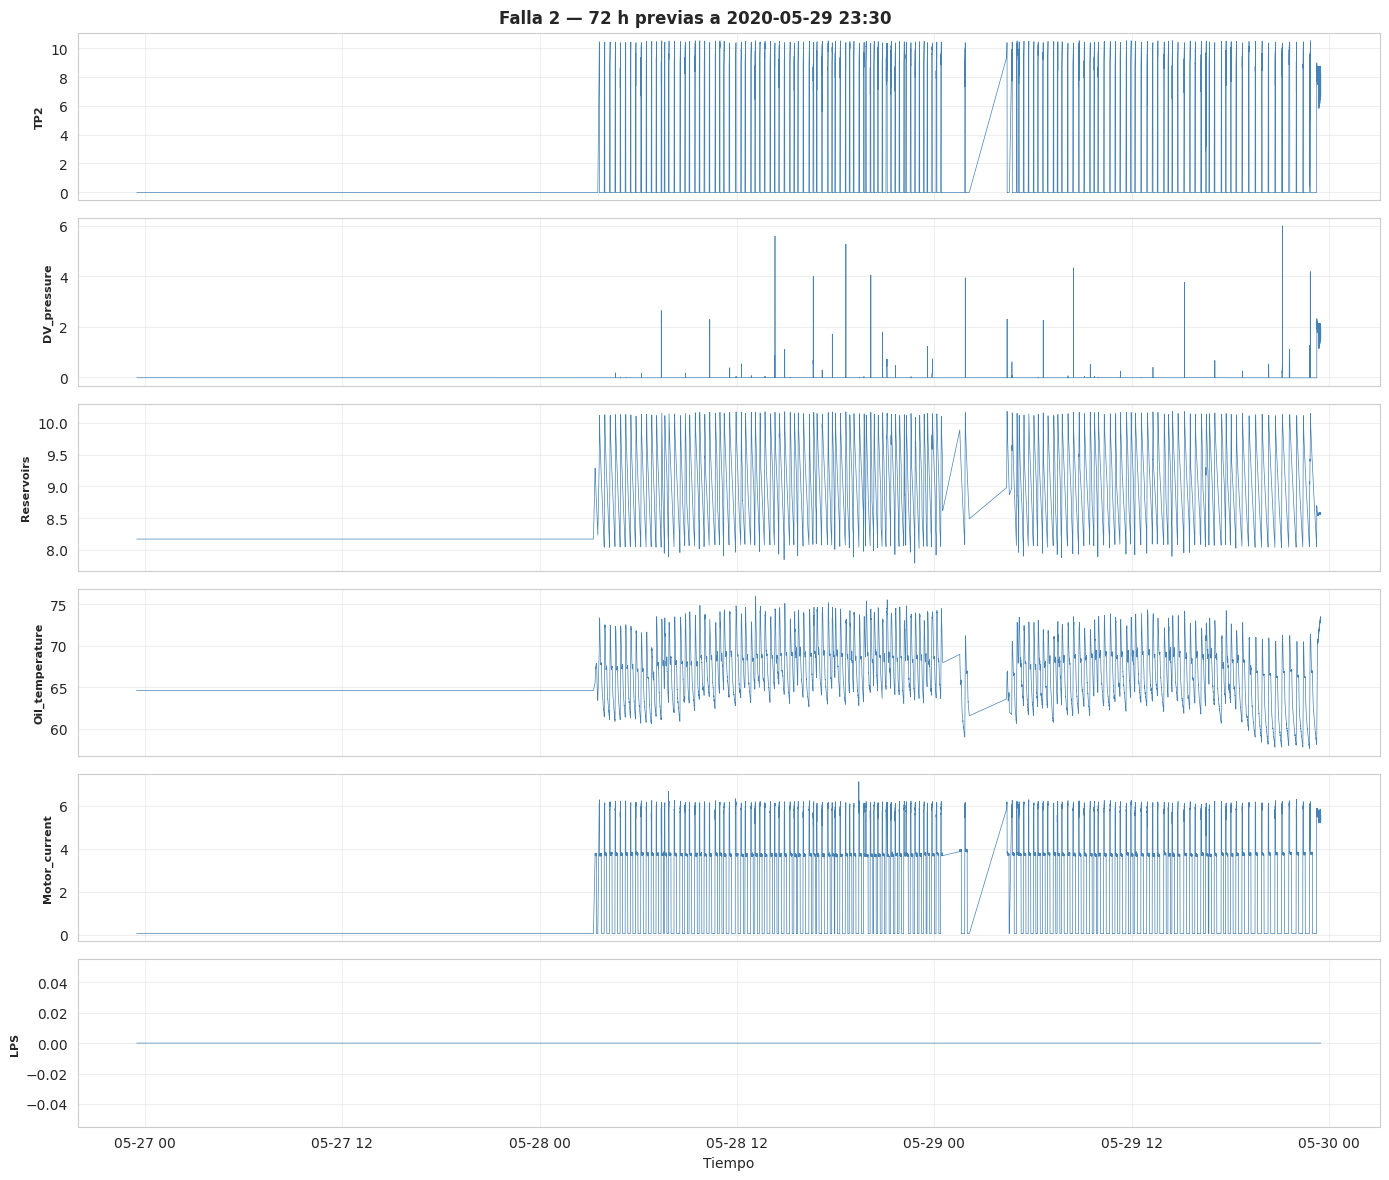

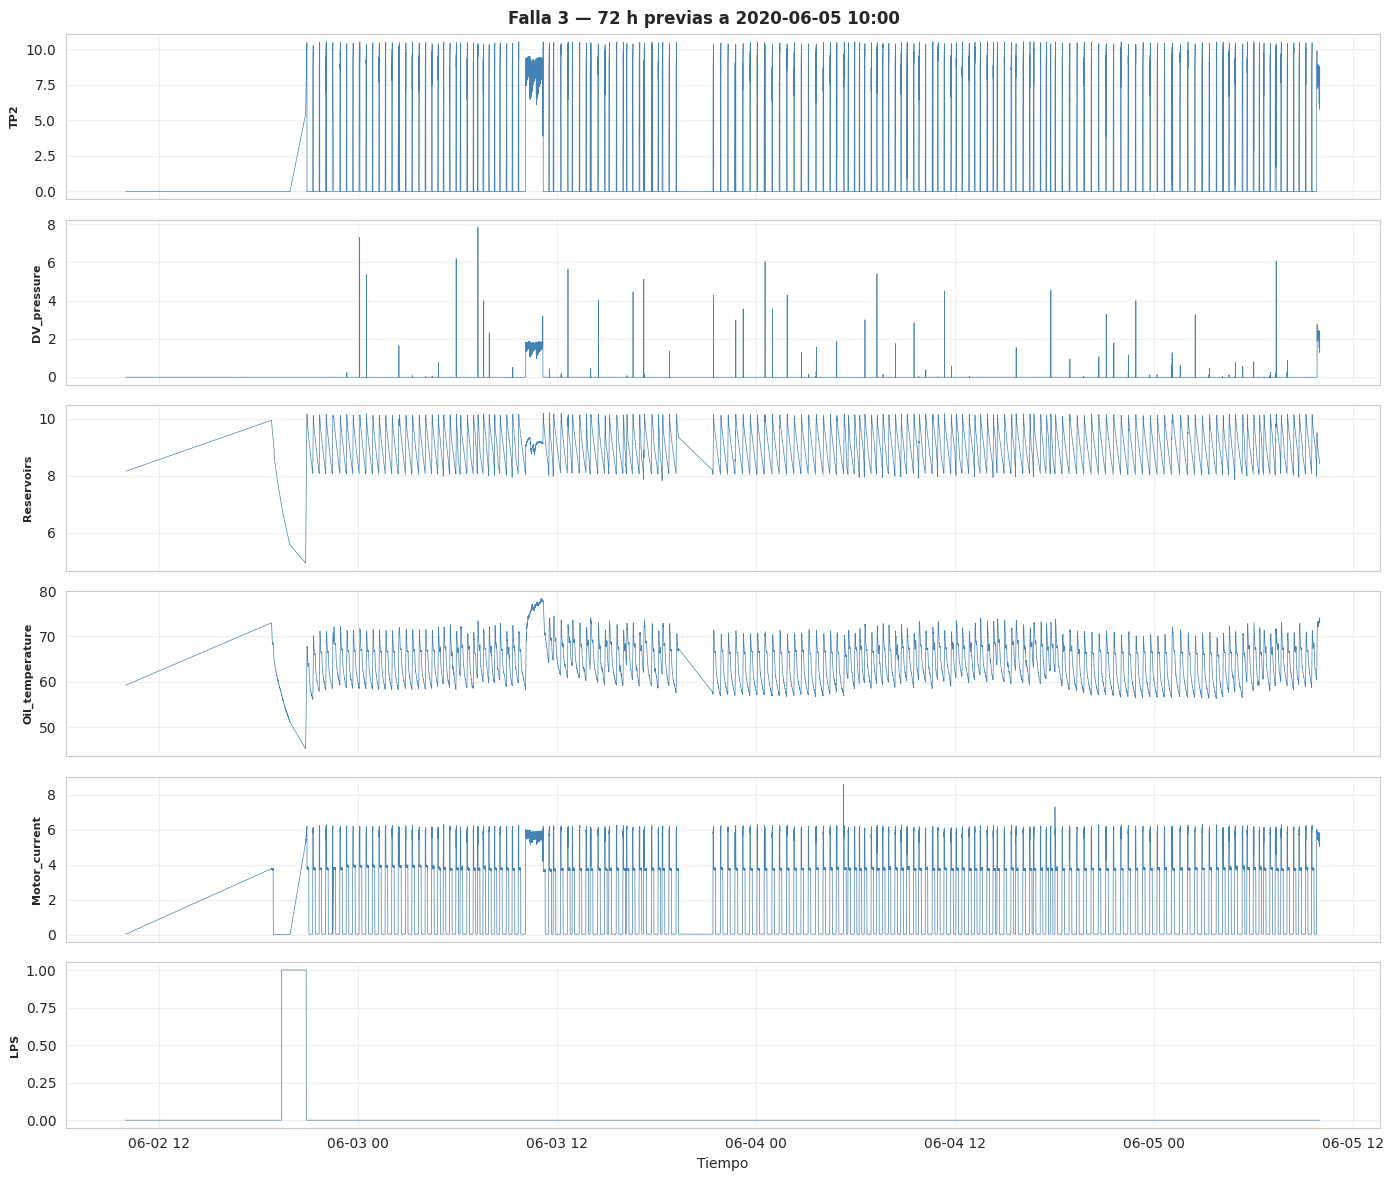

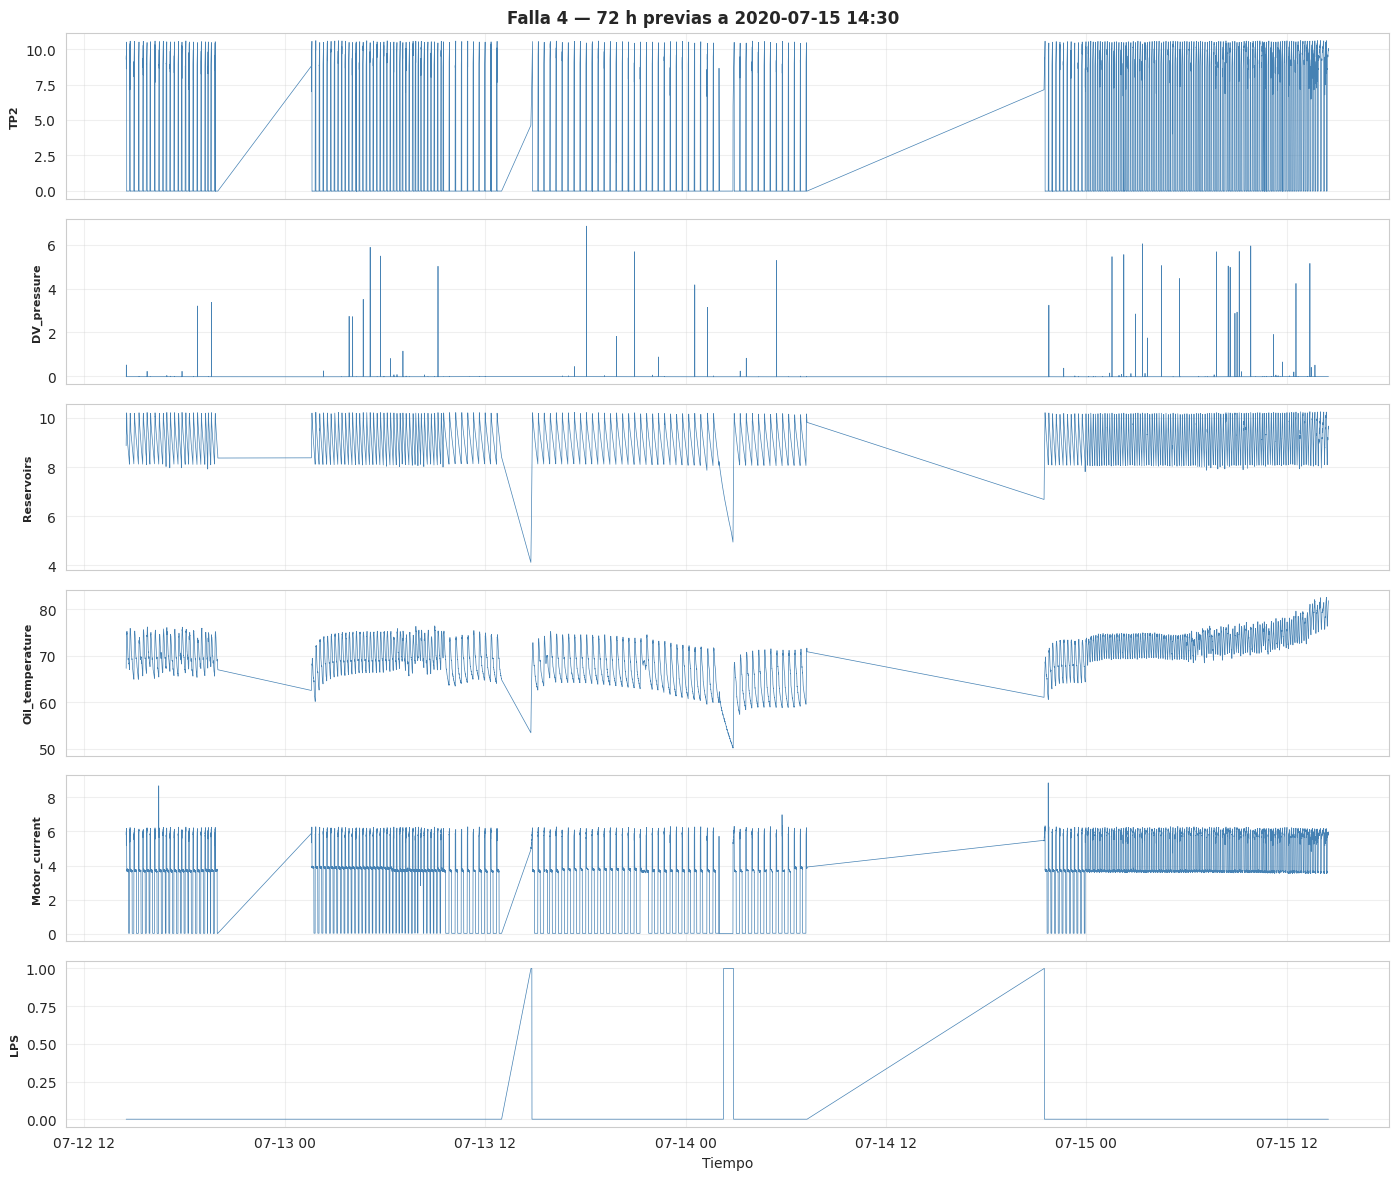

In [ ]:
os.makedirs('../img/fallas', exist_ok=True)
HORAS_ANTES = 72
sensores_falla = ['TP2', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current', 'LPS']

for nombre, ts_str in FALLAS.items():
    ts = pd.Timestamp(ts_str)
    ini = ts - pd.Timedelta(hours=HORAS_ANTES)
    v = df_full[(df_full['timestamp'] >= ini) & (df_full['timestamp'] <= ts)]
    if v.empty:
        print(f'{nombre}: sin datos')
        continue

    fig, axes = plt.subplots(len(sensores_falla), 1, figsize=(14, 2 * len(sensores_falla)),
                             sharex=True)
    for ax, col in zip(axes, sensores_falla):
        ax.plot(v['timestamp'], v[col], linewidth=0.5, color='steelblue')
        ax.set_ylabel(col, fontsize=8, fontweight='bold')
        ax.grid(alpha=0.3)
    axes[-1].set_xlabel('Tiempo')
    plt.suptitle(f'{nombre} — 72 h previas a {ts_str}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'../img/fallas/prefalla_{nombre.replace(" ", "_")}.png',
                dpi=120, bbox_inches='tight')
    plt.show()

### Cuantificar cuándo empieza la desviación

Para objetivar `RUL_MAX`, medimos el z-score de las señales de presión en las 72 h previas
respecto a su comportamiento operativo normal, y detectamos la primera hora en que la
desviación se vuelve sostenida.

In [ ]:
# Referencia de normalidad: media/std en operación (rég. 1 y 2) lejos de fallas
ref = df_op[['TP2', 'DV_pressure', 'Reservoirs']].agg(['mean', 'std'])

print('Horas antes de la falla con desviación sostenida (|z|>3 en DV_pressure):')
for nombre, ts_str in FALLAS.items():
    ts = pd.Timestamp(ts_str)
    ini = ts - pd.Timedelta(hours=72)
    v = df_full[(df_full['timestamp'] >= ini) & (df_full['timestamp'] <= ts)].copy()
    if v.empty:
        print(f'  {nombre}: sin datos'); continue
    z = (v['DV_pressure'] - ref.loc['mean', 'DV_pressure']) / ref.loc['std', 'DV_pressure']
    anomalos = v.loc[z.abs() > 3, 'timestamp']
    if len(anomalos):
        horas = (ts - anomalos.min()).total_seconds() / 3600
        print(f'  {nombre}: ~{horas:.0f} h antes')
    else:
        print(f'  {nombre}: sin desviación clara en esta ventana')

Horas antes de la falla con desviación sostenida (|z|>3 en DV_pressure):
  Falla 1: ~72 h antes
  Falla 2: ~40 h antes
  Falla 3: ~58 h antes
  Falla 4: ~68 h antes


## 7. Conclusiones y decisiones para el feature engineering (04)

### 1. `RUL_MAX`
- **RUL_MAX = 48 horas** (elegido con la evidencia impresa arriba).
- Justificación: la desviación sostenida de `DV_pressure` (|z|>3) aparece **40–72 h** antes
  de cada falla (Falla 1: ~72 h, Falla 2: ~40 h, Falla 3: ~58 h, Falla 4: ~68 h). Un
  horizonte de 48 h cubre la mediana del inicio de la degradación sin incluir demasiado periodo sano; candidato a refinar con Leave-One-Failure-Out. Corrige la estimación previa de 24 h que no coincidía con la evidencia.

### 2. Tamaño de ventana
- **Ventana = 60 minutos.**
- Justificación: el ACF estacional muestra memoria significativa de 1–2 h; el ciclo operacional
  es de ~9 min, así que 60 min capturan ~6 ciclos. Buen equilibrio información/costo.

### 3. Priorización de señales
- **Presión (TP2, DV_pressure, Reservoirs, TP3, H1):** las más informativas para fugas de aire.
- **Oil_temperature:** degradación térmica gradual.
- **Motor_current + binarias (DV_eletric, COMP, MPG):** definen régimen y ciclado.
- **LPS:** evento raro que aumenta cerca de fallas de presión → útil como feature de conteo.
- Resolver redundancia TP3↔Reservoirs con selección de features en el 05.

### 4. Estrategia de normalización
- Normalización **por sesión** (z-score) para las señales con deriva térmica; estandarización
  global para el resto. Se aplicará en el 04.

### Entrada al notebook 04 (feature engineering)
- Base temporal: `preprocesado_completo.parquet` para construir la etiqueta RUL (tiempo real
  hasta la falla) respetando continuidad; features operativas desde `operacional.parquet`.
- `RUL_MAX = 48 h`, `ventana = 60 min`.